In [1]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import math


# Load the CSV file
csv_file = "dataset-siginf-cc-2026.csv"
data = pd.read_csv(csv_file)
print(data)

           time  power import building 1 [watts]  \
0      00:00:00                       280.385475   
1      00:15:00                       280.631285   
2      00:30:00                       609.050279   
3      00:45:00                       316.078212   
4      01:00:00                       314.357542   
...         ...                              ...   
35131  22:45:00                       312.983240   
35132  23:00:00                       312.905028   
35133  23:15:00                       312.307263   
35134  23:30:00                       312.899441   
35135  23:45:00                       306.363128   

       power export building 1 [watts]  power import building 2 [watts]  \
0                                  0.0                      1830.256983   
1                                  0.0                      2543.480447   
2                                  0.0                      2393.027778   
3                                  0.0                       334.661111   


### 0. Init
There are 35'136 rows of data each serperated by 15min.
This means that the duration of the recording is 15*35136 minutes, which divided by 60 then 24 gives 366 days.

The data is in form of floating point numbers aswell as NaN entries (which we will need to take into account when plotting).

### 1. What is the channel of the recordings?
Electrical

### 2. What is the dimensionality of the signal?
2 dimensional because there is time and a number (the power value)

### 3. What are the possible source of noise and how can I filter them?
TODO
Don't know

### 4. At how many different scale can we parse these data?
Every 15 minutes is the bear minimum and up to 366 days as a maximum.

### 5. What is the optimal scale at which I can study these data? Justify.
TODO

### 6. How long have these data been acquired for?
366 days

### 7. When did the recording start (hint: at least identify the season)?
In order to determine this, we must plot the data.

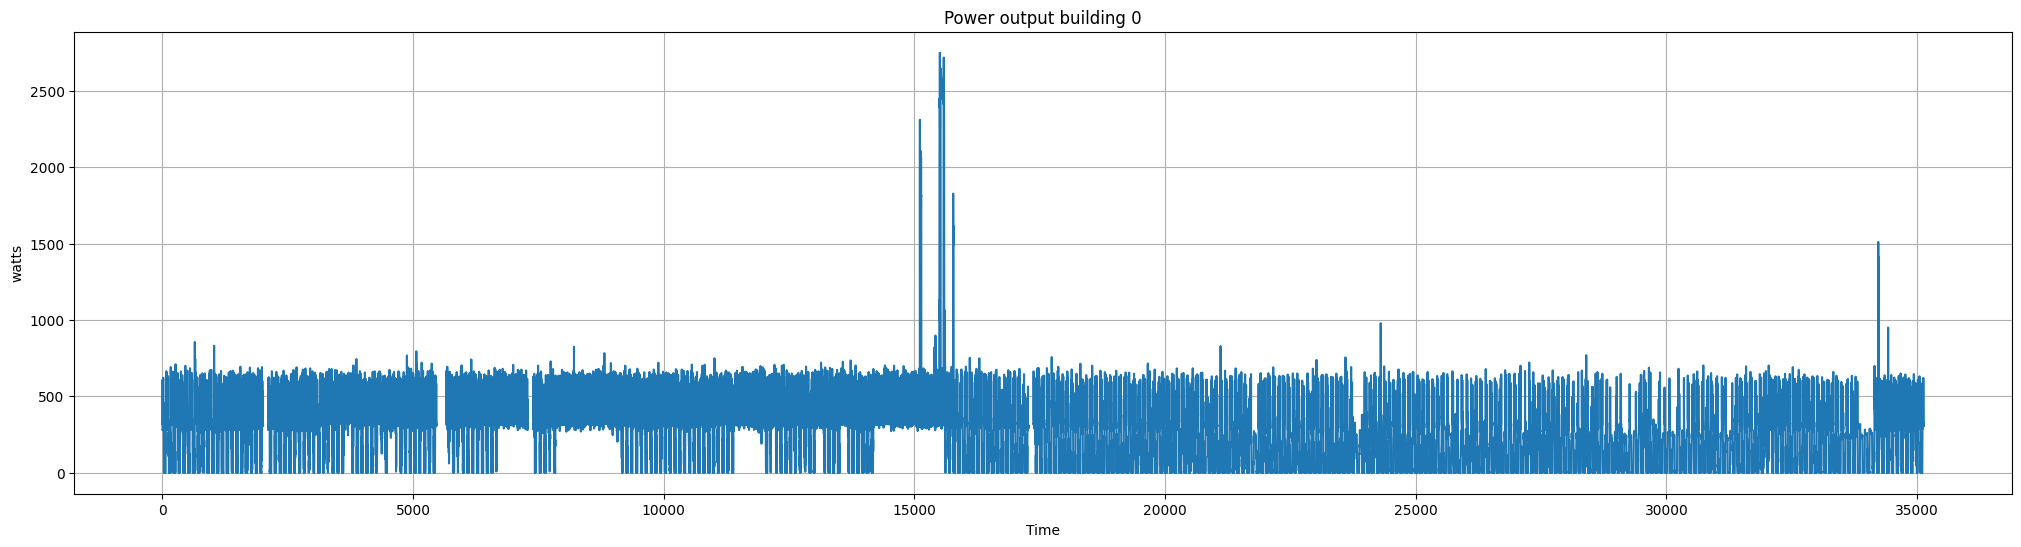

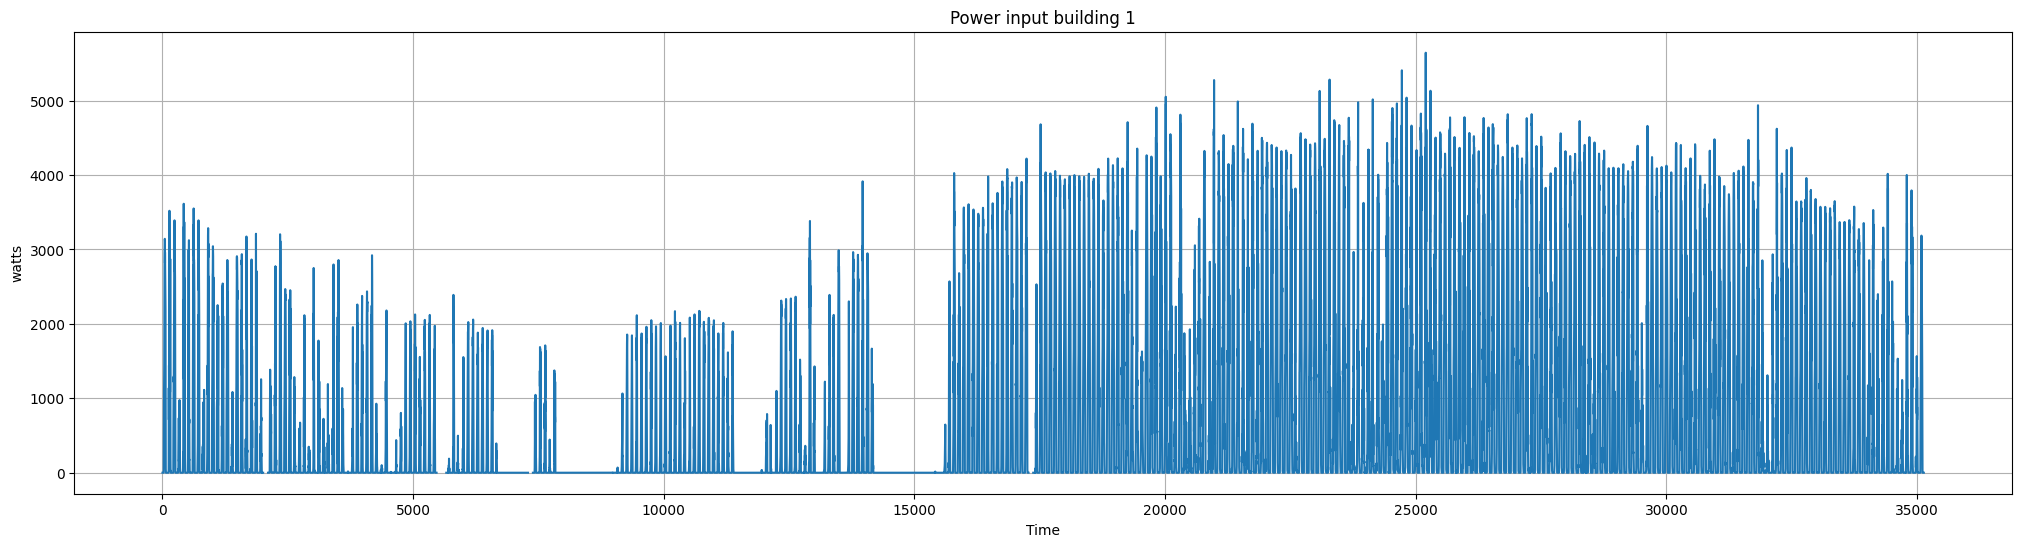

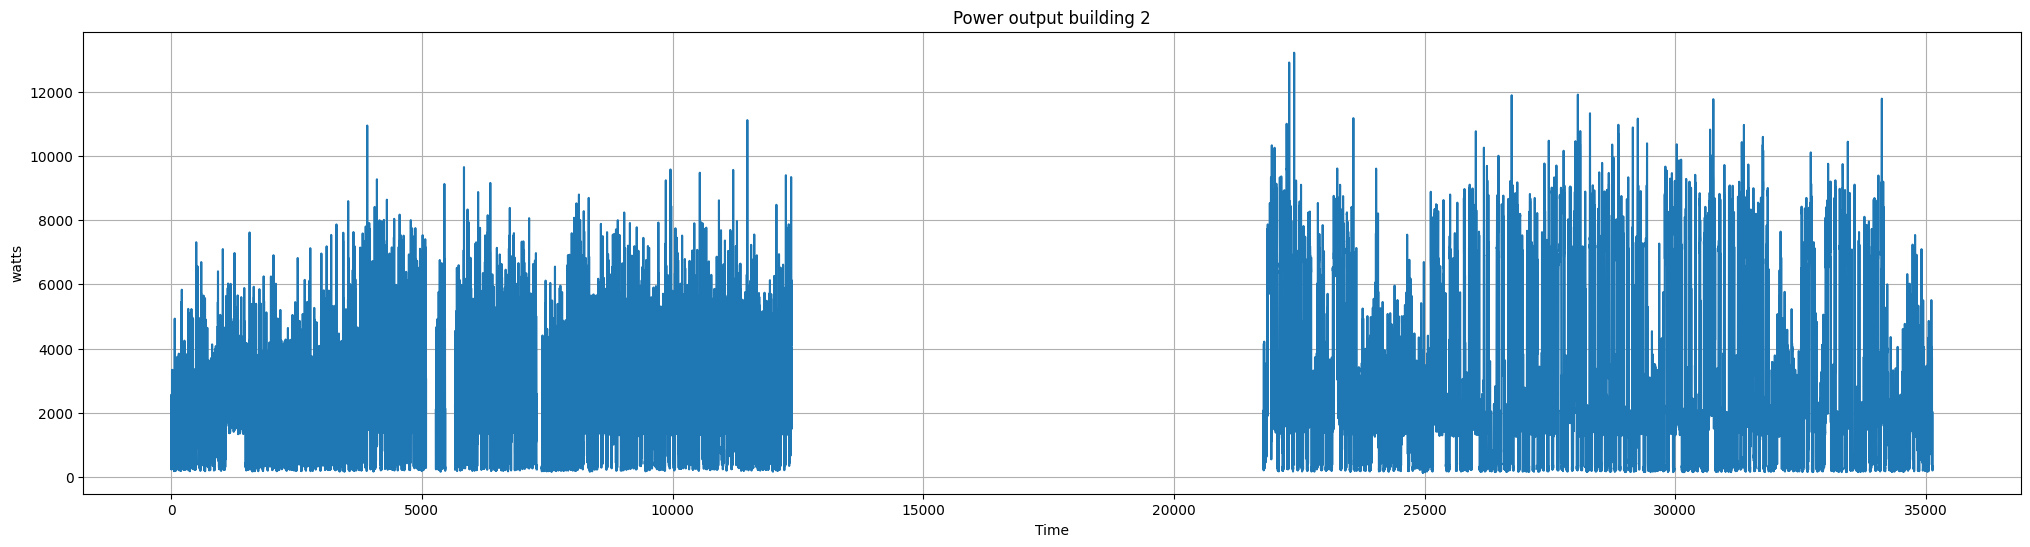

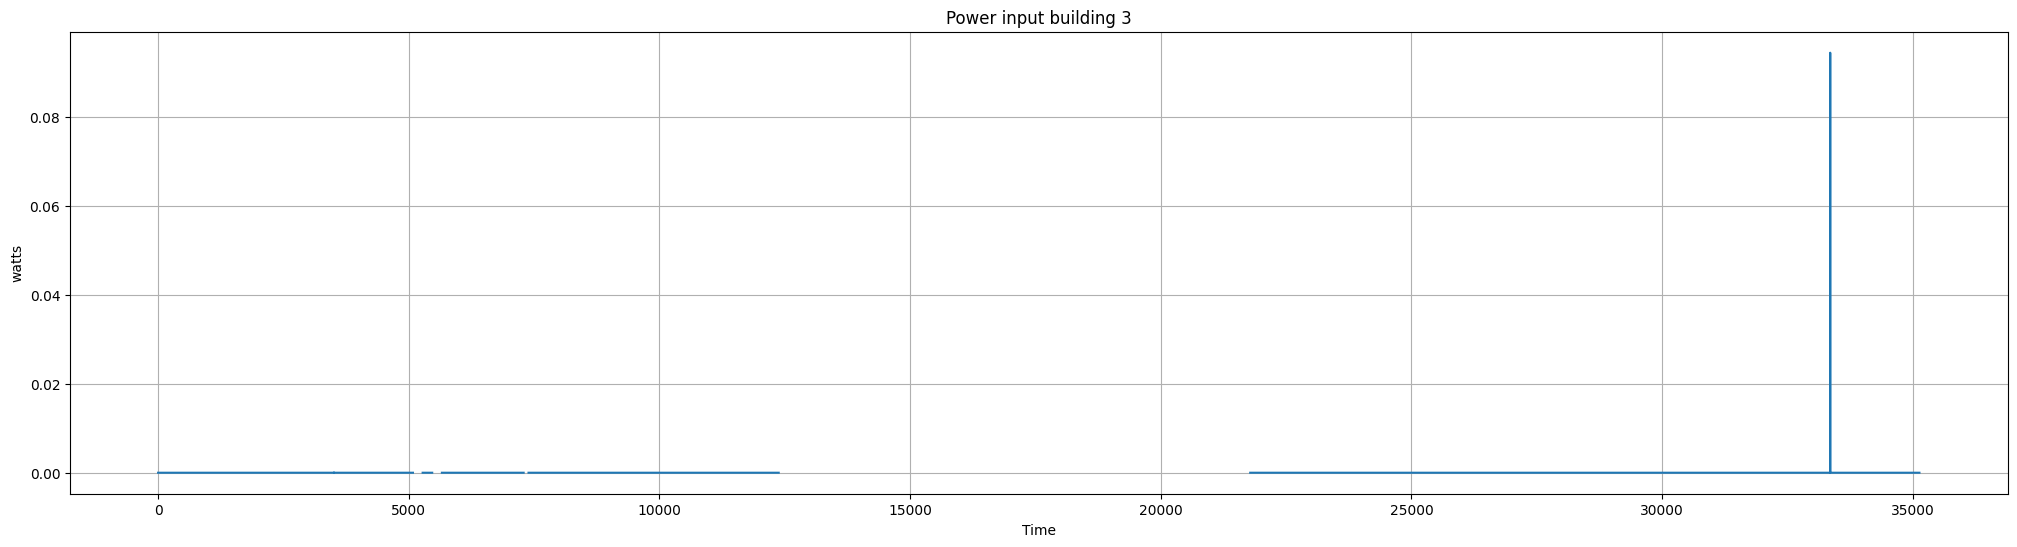

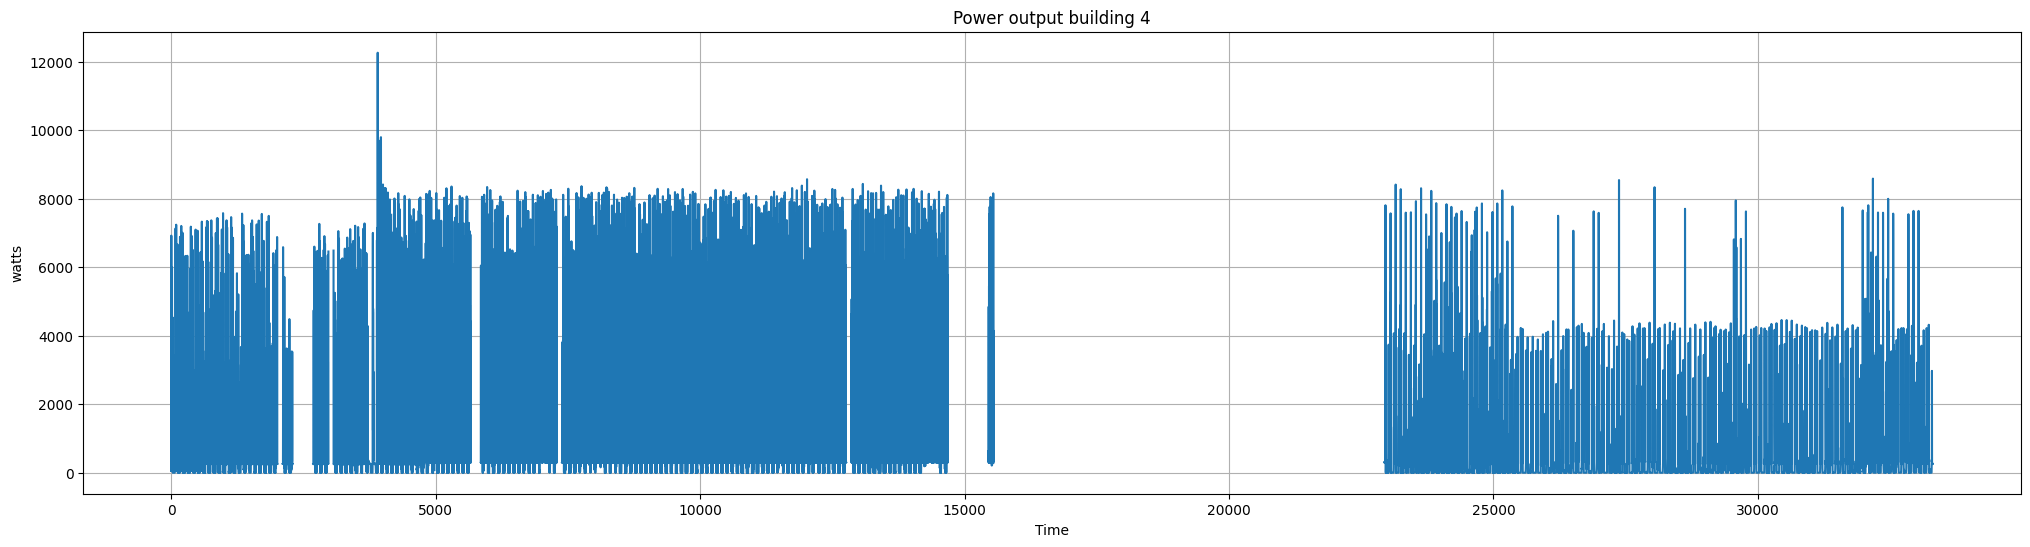

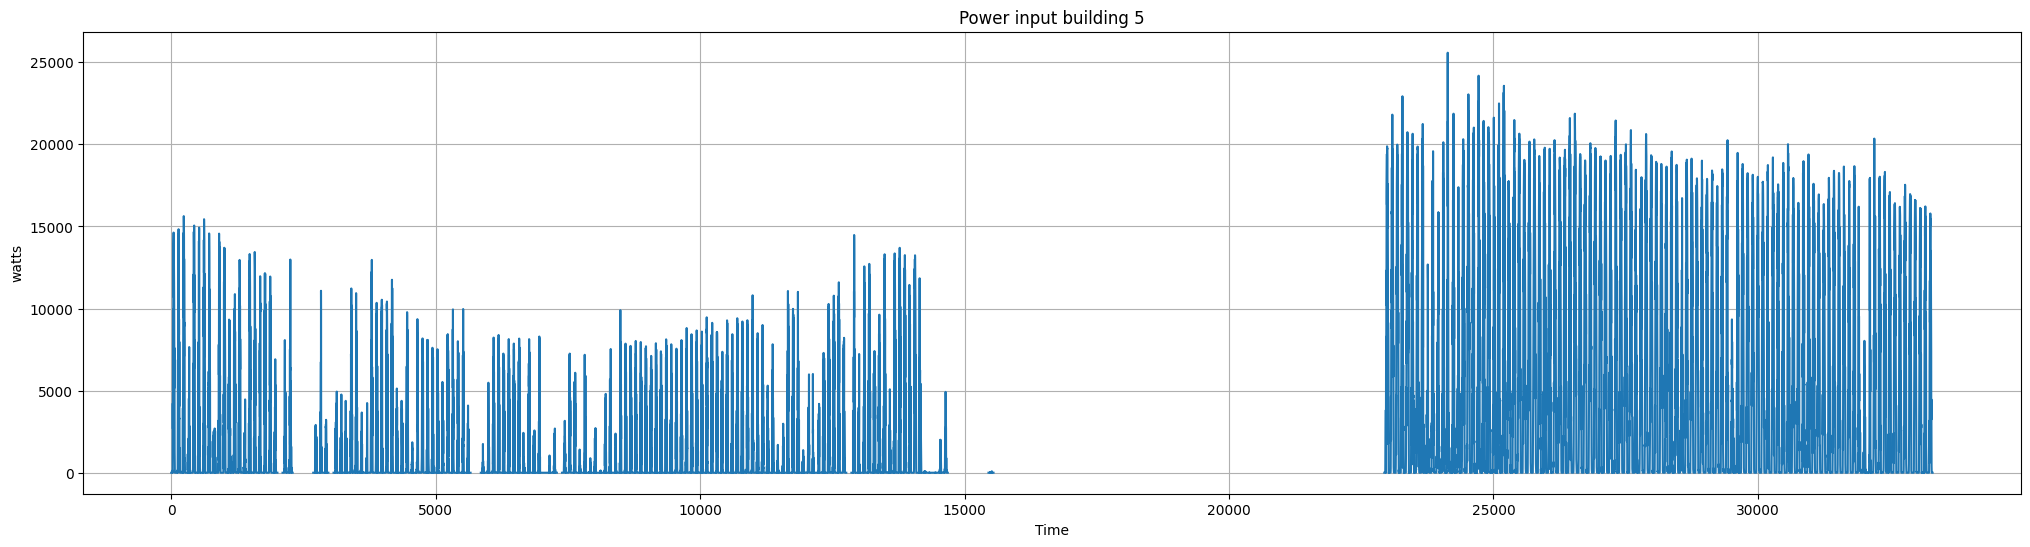

In [5]:
ib1 = data["power import building 1 [watts]"]
eb1 = data["power export building 1 [watts]"]

ib2 = data["power import building 2 [watts]"]
eb2 = data["power export building 2 [watts]"]

ib3 = data["power import building 3 [watts]"]
eb3 = data["power export building 3 [watts]"]

all = [ib1, eb1, ib2, eb2, ib3, eb3]

def plot_f(data, number, output_input_type):
    plt.figure(figsize=(25, 6))
    plt.plot(data)
    plt.xlabel("Time")
    plt.ylabel("watts")
    plt.title(f"Power {output_input_type} building {number}")
    plt.grid()
    plt.show()

for index, value in enumerate(all):
    t = "input"
    if index%2==0:
        t = "output"
    plot_f(value, index, t)

Inital observations:
1. constant
2. can imagine a constant curve. There are holes so could potentially be noise or sensor malfunctions.

3. fairly random except for the large hole in the middle.
4. 0 or extremly negligeble power values (under 0.1 watts), especially in comparison with the second lowest which is around 500 watts.

5. fairly uniform except for the large hole in the middle.
6. idem


Our best shot at estimating the beginning date of this study would be by taking the graphs with the large gapes in them.\
First of all, 5000 units on the x axis represents $5000*15/60/24/7 = 52 days / 7 = 7.44$ weeks or 1.86 months, so just under 2 months.

This means we can estimate the gaps lasted between 3 and 4 months.

For 2 building outputs they happen for the same amount of time within a small time difference.

For power production, there is really only two options that are dependant on the time of year:
- solar power -> sun being covered with bad weather, weaker sun rays/coverage and shorter suntime
- hydrolic -> frozen lake maybe

This means that at least both gaps happen during the winter.

The earliest being at the 12'500 mark. So we take November as the start of Winter we work backwards. $12'500*15/60/24/7 = 18.6$ weeks or 4.65 months. This means that the study probably started in **the middle of June**. So start of summer.


### 8. Can you identify any recurrent pattern in consumption? Justify.
TODO
### 9. Can you identify any recurrent pattern in production? Justify. In your opinion, what is the source of electricity production?
TODO
### 10. Provide an explanatory text of the performed analyses and conclusions, basing your answer on the previous tasks. What kind of building could the data come from?
TODO